In [2]:
from __future__ import annotations
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt


def elbow_plot_from_results_tree(
    results_base: str | Path,
    metric: str = "mae",                 # "mae" or "mse"
    csv_glob: str = "bin_*/cv_metrics_train_*.csv",
    out_png: str | Path | None = None,
    out_csv: str | Path | None = None,
    title: str | None = None,
    verbose: bool = True,
):
    """
    Read refactored CV CSVs from:
        results_base/bin_XXXX/cv_metrics_train_XXXX.csv

    Expected CSV columns:
        mode,k_channels,mse,mae

    Produces:
      - wide summary CSV: index=bin_size, columns=model, value=metric
      - elbow plot PNG
    """
    results_base = Path(results_base)

    paths = sorted(results_base.glob(csv_glob))
    if not paths:
        raise FileNotFoundError(f"No CSVs matched {csv_glob} under {results_base}")

    rows = []
    for fp in paths:
        # infer bin from folder name bin_XXXX
        m = re.search(r"bin_(\d+)", str(fp.parent))
        if not m:
            if verbose:
                print(f"[SKIP] {fp} -> cannot infer bin size from parent folder")
            continue
        bin_size = int(m.group(1))

        df = pd.read_csv(fp)
        if metric not in df.columns:
            raise ValueError(f"{fp} missing metric '{metric}', has {list(df.columns)}")

        # take only the core modes you care about (keeps plot clean)
        keep = {"rms_matrix", "all_channels", "average_channels"}
        df = df[df["mode"].astype(str).isin(keep)].copy()

        for _, r in df.iterrows():
            rows.append({
                "bin_size": bin_size,
                "model": str(r["mode"]),
                metric: float(r[metric]),
                "csv": fp.name,
            })

    long = pd.DataFrame(rows)
    if long.empty:
        raise RuntimeError("No usable rows collected (check CSV schema / mode names).")

    summary = (
        long.pivot_table(index="bin_size", columns="model", values=metric, aggfunc="first")
            .sort_index()
    )

    if out_csv is None:
        out_csv = results_base / f"elbow_summary_{metric}.csv"
    if out_png is None:
        out_png = results_base / f"elbow_{metric}.png"

    summary.to_csv(out_csv)

    # --- plot
    plt.figure(figsize=(7.6, 4.3))
    x = summary.index.values

    order = [c for c in ["rms_matrix", "all_channels", "average_channels"] if c in summary.columns]
    for c in order:
        plt.plot(x, summary[c].values, marker="o", label=c)

    plt.xlabel("Bin size (samples)")
    plt.ylabel(("MAE ↓" if metric == "mae" else "MSE ↓"))
    plt.title(title or f"{results_base.name}: {metric.upper()} vs bin size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()

    if verbose:
        print(f"[FOUND] {len(paths)} csv files")
        print(f"[SAVE] {out_csv}")
        print(f"[PLOT] {out_png}")
        print(f"[BINS] {list(summary.index)}")
        print(f"[COLS] {list(summary.columns)}")

    return {"long": long, "summary": summary, "out_csv": Path(out_csv), "out_png": Path(out_png)}

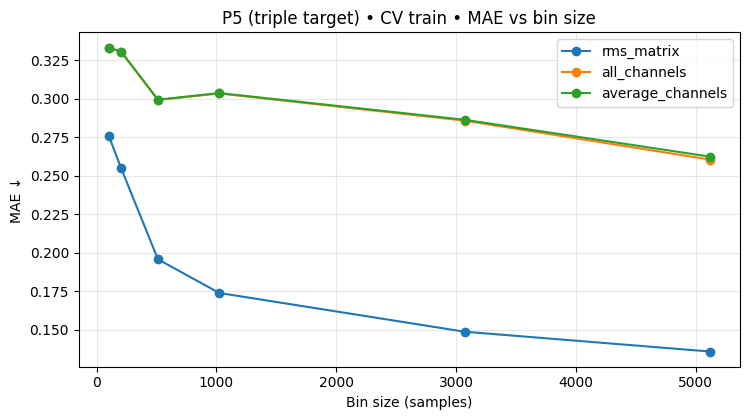

[FOUND] 6 csv files
[SAVE] results/P5_triple/elbow_summary_mae.csv
[PLOT] results/P5_triple/elbow_mae.png
[BINS] [102, 205, 512, 1024, 3072, 5120]
[COLS] ['all_channels', 'average_channels', 'rms_matrix']


{'long':     bin_size             model       mae                        csv
 0        102        rms_matrix  0.275763   cv_metrics_train_102.csv
 1        102      all_channels  0.333182   cv_metrics_train_102.csv
 2        102  average_channels  0.333045   cv_metrics_train_102.csv
 3       1024        rms_matrix  0.173906  cv_metrics_train_1024.csv
 4       1024      all_channels  0.303375  cv_metrics_train_1024.csv
 5       1024  average_channels  0.303634  cv_metrics_train_1024.csv
 6        205        rms_matrix  0.254800   cv_metrics_train_205.csv
 7        205      all_channels  0.330430   cv_metrics_train_205.csv
 8        205  average_channels  0.330513   cv_metrics_train_205.csv
 9       3072        rms_matrix  0.148769  cv_metrics_train_3072.csv
 10      3072      all_channels  0.285740  cv_metrics_train_3072.csv
 11      3072  average_channels  0.286299  cv_metrics_train_3072.csv
 12       512        rms_matrix  0.195755   cv_metrics_train_512.csv
 13       512      all_cha

In [3]:
elbow_plot_from_results_tree(
    results_base="results/P5_triple",
    metric="mae",
    title="P5 (triple target) • CV train • MAE vs bin size"
)

[PATH] combined-dir: /Users/juliahagen/IntMS_EEG/data/preprocessing/P5_combined -> resolved: /Users/juliahagen/IntMS_EEG/data/preprocessing/P5_combined
[PATH] matched files: 6
[LOAD] bin_len=3072: X_by_mode keys=['rms_matrix'], y=(559, 3), groups=12
[DONE] processed files: 6/6
[SAVE] /Users/juliahagen/IntMS_EEG/results/P5_triple/bin_3072/feature_target_correlations_TEST.csv


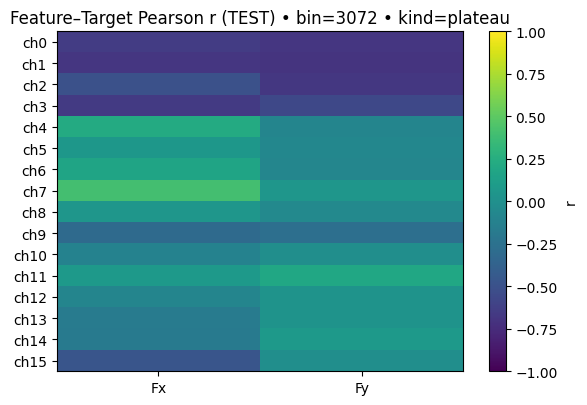

[PLOT] /Users/juliahagen/IntMS_EEG/results/P5_triple/bin_3072/feature_target_corr_TEST_FxFy.png


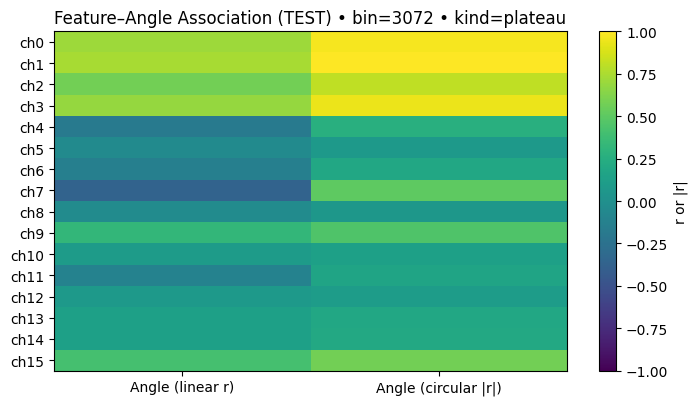

[PLOT] /Users/juliahagen/IntMS_EEG/results/P5_triple/bin_3072/feature_target_corr_TEST_Angle.png


,r_Fx,r_Fy,r_Angle_lin,r_Angle_circ_mag
ch0,-0.648421,-0.687068,0.703867,0.973664
ch1,-0.683942,-0.699757,0.737088,1.018690
ch2,-0.504378,-0.677990,0.576516,0.805317
ch3,-0.657083,-0.564996,0.685604,0.944947
ch4,0.221645,-0.088959,-0.177008,0.261444
ch5,0.061537,-0.072519,-0.041473,0.074774
ch6,0.171429,-0.081361,-0.135238,0.202013
ch7,0.400320,0.047175,-0.360222,0.502392
ch8,0.051235,-0.061459,-0.034711,0.061496
ch9,-0.312270,-0.271896,0.324750,0.448131


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiments_xy import collect_dataset_from_combined, split_one_plateau_per_angle_test


# ------------------ correlations helpers ------------------

def _safe_pearsonr(x, y):
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan
    x = x[m]; y = y[m]
    sx = np.std(x); sy = np.std(y)
    if sx == 0 or sy == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _angle_circular_linear_r(feature, angle_deg):
    """
    Circular-linear association:
      r(feature, sin(angle)) and r(feature, cos(angle)),
      resultant magnitude sqrt(r_sin^2 + r_cos^2) in [0,1].
    """
    ang = np.deg2rad(np.asarray(angle_deg, float).ravel())
    s = np.sin(ang); c = np.cos(ang)
    r_s = _safe_pearsonr(feature, s)
    r_c = _safe_pearsonr(feature, c)
    if np.isnan(r_s) or np.isnan(r_c):
        return np.nan
    return float(np.sqrt(r_s**2 + r_c**2))


def _apply_channel_permutation(X, perm):
    """
    Reorder columns of X (N,C) with a permutation 'perm' of length C.
    perm is interpreted as: new_X[:, j] = old_X[:, perm[j]].
    """
    X = np.asarray(X)
    perm = np.asarray(perm, dtype=int).ravel()
    if X.ndim != 2:
        raise ValueError(f"X must be 2D (N,C), got shape={X.shape}")
    C = X.shape[1]
    if perm.size != C:
        raise ValueError(f"perm must have length C={C}, got {perm.size}")
    if sorted(perm.tolist()) != list(range(C)):
        raise ValueError(f"perm must be a permutation of 0..{C-1}, got {perm}")
    return X[:, perm]


def compute_test_correlations_for_bin_new(
    combined_dir_or_glob: str,
    results_root: str,
    bin_len: int,
    kind: str = "plateau",
    rng: int = 42,
    fs_assumed: float = 10240.0,   # only used to convert bin_len -> bin_sec
    rms_win_samples: int = 100,
    channel_names=None,
    channel_perm=None,             # <-- NEW: pass a permutation list/array here
    save: bool = True,
):
    """
    Uses refactored pipeline output:
      buckets[bin_len]["X_by_mode"]["rms_matrix"], ["y"], ["groups"], ["nominal_angles"]

    Computes correlations on TEST split (one plateau per nominal angle).
    Saves CSV + 2 heatmaps under results_root/bin_{bin_len}/
    """
    combined_dir = str(Path(combined_dir_or_glob).expanduser().resolve())
    results_root = Path(results_root).expanduser().resolve()
    bin_dir = results_root / f"bin_{int(bin_len)}"
    bin_dir.mkdir(parents=True, exist_ok=True)

    # Convert desired bin_len (samples) into bin_sec for the collector
    bin_sec = float(bin_len) / float(fs_assumed)

    buckets = collect_dataset_from_combined(
        combined_dir,
        bin_sec=bin_sec,
        include_angle_target=True,
        rms_win_samples=rms_win_samples,
        modes=("rms_matrix",),
        segment_kind=kind,
    )

    key = int(bin_len)
    if key not in buckets:
        # rounding / fs-estimation may shift key by a few samples -> pick closest
        avail = sorted(buckets.keys())
        closest = min(avail, key=lambda k: abs(k - key))
        print(f"[WARN] Requested bin_len={key} not found. Using closest available={closest}.")
        key = closest

    bundle = buckets[key]
    X = bundle["X_by_mode"]["rms_matrix"]     # (N, C)
    y = bundle["y"]                           # (N, 3): Fx, Fy, Angle
    groups = bundle["groups"]                 # (N,)
    nominal_angles = bundle["nominal_angles"] # (N,)

    # ---------- OPTIONAL: fix channel ordering ex post ----------
    if channel_perm is not None:
        X = _apply_channel_permutation(X, channel_perm)
        if channel_names is not None:
            if len(channel_names) != X.shape[1]:
                raise ValueError(f"channel_names must have length {X.shape[1]}, got {len(channel_names)}")
            channel_names = [channel_names[i] for i in channel_perm]

    # leakage-safe split
    train_idx, test_idx, test_groups = split_one_plateau_per_angle_test(
        groups, nominal_angles, rng=rng
    )
    X_te = X[test_idx]
    y_te = y[test_idx]

    C = X_te.shape[1]
    if channel_names is None:
        feature_names = [f"ch{i}" for i in range(C)]
    else:
        if len(channel_names) != C:
            raise ValueError(f"channel_names must have length {C}, got {len(channel_names)}")
        feature_names = list(channel_names)

    # correlations
    r_fx = np.array([_safe_pearsonr(X_te[:, i], y_te[:, 0]) for i in range(C)], float)
    r_fy = np.array([_safe_pearsonr(X_te[:, i], y_te[:, 1]) for i in range(C)], float)
    r_ang_lin = np.array([_safe_pearsonr(X_te[:, i], y_te[:, 2]) for i in range(C)], float)
    r_ang_circ = np.array([_angle_circular_linear_r(X_te[:, i], y_te[:, 2]) for i in range(C)], float)

    corr_df = pd.DataFrame(
        {
            "r_Fx": r_fx,
            "r_Fy": r_fy,
            "r_Angle_lin": r_ang_lin,
            "r_Angle_circ_mag": r_ang_circ,
        },
        index=feature_names,
    )

    if save:
        out_csv = bin_dir / "feature_target_correlations_TEST.csv"
        corr_df.to_csv(out_csv)
        print(f"[SAVE] {out_csv}")

        # ---------- plot Fx/Fy heatmap ----------
        fig1 = plt.figure(figsize=(6, max(3.5, 0.26 * C)))
        ax1 = fig1.add_subplot(111)
        mat = np.column_stack([corr_df["r_Fx"].values, corr_df["r_Fy"].values])
        im = ax1.imshow(mat, aspect="auto", origin="upper", vmin=-1, vmax=1)
        ax1.set_yticks(range(C)); ax1.set_yticklabels(feature_names)
        ax1.set_xticks([0, 1]); ax1.set_xticklabels(["Fx", "Fy"])
        ax1.set_title(f"Feature–Target Pearson r (TEST) • bin={key} • kind={kind}")
        fig1.colorbar(im, ax=ax1, label="r")
        fig1.tight_layout()
        out_png1 = bin_dir / "feature_target_corr_TEST_FxFy.png"
        fig1.savefig(out_png1, dpi=150)
        plt.show()
        print(f"[PLOT] {out_png1}")

        # ---------- plot Angle heatmap ----------
        fig2 = plt.figure(figsize=(7.2, max(3.5, 0.26 * C)))
        ax2 = fig2.add_subplot(111)
        mat2 = np.column_stack([corr_df["r_Angle_lin"].values, corr_df["r_Angle_circ_mag"].values])
        im2 = ax2.imshow(mat2, aspect="auto", origin="upper", vmin=-1, vmax=1)
        ax2.set_yticks(range(C)); ax2.set_yticklabels(feature_names)
        ax2.set_xticks([0, 1]); ax2.set_xticklabels(["Angle (linear r)", "Angle (circular |r|)"])
        ax2.set_title(f"Feature–Angle Association (TEST) • bin={key} • kind={kind}")
        fig2.colorbar(im2, ax=ax2, label="r or |r|")
        fig2.tight_layout()
        out_png2 = bin_dir / "feature_target_corr_TEST_Angle.png"
        fig2.savefig(out_png2, dpi=150)
        plt.show()
        print(f"[PLOT] {out_png2}")

    return corr_df, bin_dir


# ------------------ Example usage ------------------

# If you believe channels are interleaved (0 next to 2 next to 4 ...), try this for 16 channels:
perm16 = [0, 2, 4, 6, 8, 10, 12, 14, 1, 3, 5, 7, 9, 11, 13, 15]

corr_df, out_dir = compute_test_correlations_for_bin_new(
    combined_dir_or_glob="data/preprocessing/P5_combined",
    results_root="results/P5_triple",
    bin_len=3072,
    kind="plateau",
    rng=42,
    channel_perm=perm16,   # <-- HERE is where you "enter it"
)
display(corr_df)

,Bin size (samples),Duration (ms),MAE (rms_matrix),MAE (all_channels),MAE (average_channels)
0,102,9.960938,0.275763,0.333182,0.333045
1,205,20.019531,0.254800,0.330430,0.330513
2,512,50.000000,0.195755,0.299158,0.299337
3,1024,100.000000,0.173906,0.303375,0.303634
4,3072,300.000000,0.148769,0.285740,0.286299
5,5120,500.000000,0.135915,0.260477,0.262400


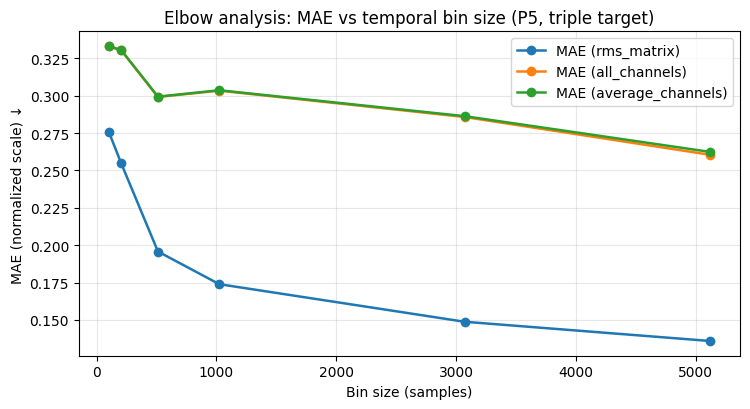

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# adjust if your files live elsewhere
csvs = {
    102:  Path("results/P5_triple/bin_102/cv_metrics_train_102.csv"),
    205:  Path("results/P5_triple/bin_205/cv_metrics_train_205.csv"),
    512:  Path("results/P5_triple/bin_512/cv_metrics_train_512.csv"),
    1024: Path("results/P5_triple/bin_1024/cv_metrics_train_1024.csv"),
    3072: Path("results/P5_triple/bin_3072/cv_metrics_train_3072.csv"),
    5120: Path("results/P5_triple/bin_5120/cv_metrics_train_5120.csv"),
}

fs = 10240.0

rows = []
for bin_len, p in csvs.items():
    df = pd.read_csv(p)
    # Expect: columns like ["mode","k_channels","mse","mae"]
    def get_mae(mode):
        s = df.loc[df["mode"] == mode, "mae"]
        return float(s.iloc[0]) if len(s) else np.nan

    rows.append({
        "Bin size (samples)": bin_len,
        "Duration (ms)": 1000.0 * (bin_len / fs),
        "MAE (rms_matrix)": get_mae("rms_matrix"),
        "MAE (all_channels)": get_mae("all_channels"),
        "MAE (average_channels)": get_mae("average_channels"),
    })

table = pd.DataFrame(rows).sort_values("Bin size (samples)")
display(table)

# elbow plot (MAE vs bin size)
plt.figure(figsize=(7.6, 4.2))
for col in ["MAE (rms_matrix)", "MAE (all_channels)", "MAE (average_channels)"]:
    plt.plot(table["Bin size (samples)"], table[col], marker="o", lw=1.8, label=col)

plt.xlabel("Bin size (samples)")
plt.ylabel("MAE (normalized scale) ↓")
plt.title("Elbow analysis: MAE vs temporal bin size (P5, triple target)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[PATH] combined-dir: data/preprocessing/P5_combined -> resolved: /Users/juliahagen/IntMS_EEG/data/preprocessing/P5_combined
[PATH] matched files: 6
[LOAD] bin_len=3072: X_by_mode keys=['rms_matrix'], y=(559, 3), groups=12
[DONE] processed files: 6/6


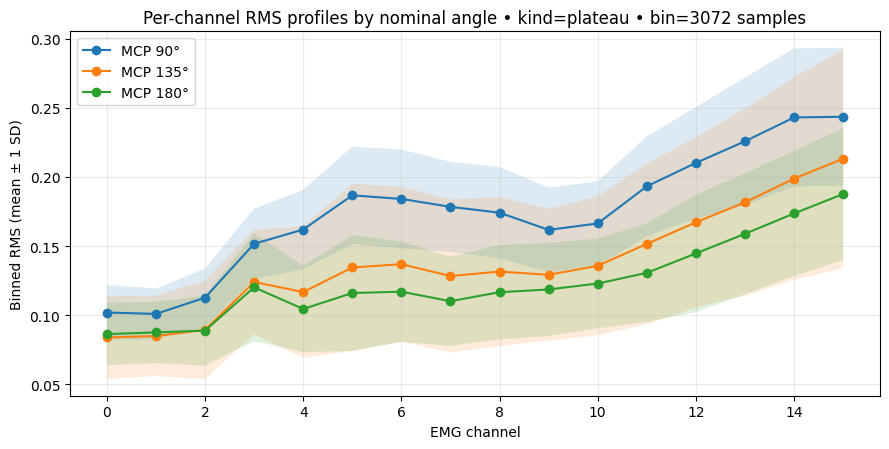

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from experiments_xy import collect_dataset_from_combined  # your refactored loader

# --- your channel re-ordering ---
perm16 = [0, 2, 4, 6, 8, 10, 12, 14, 1, 3, 5, 7, 9, 11, 13, 15]

def plot_channel_profiles_by_nominal_angle(
    combined_dir="data/preprocessing/P5_combined",
    bin_len=3072,
    kind="plateau",
    fs=10240.0,
    perm=None,
    relabel_xticks=True,
):
    # bin_len -> bin_sec (collector API)
    bin_sec = float(bin_len) / float(fs)

    buckets = collect_dataset_from_combined(
        combined_dir,
        bin_sec=bin_sec,
        include_angle_target=True,
        rms_win_samples=100,
        modes=("rms_matrix",),
        segment_kind=kind,
    )

    # pick closest key in case rounding differs
    key = int(bin_len)
    if key not in buckets:
        avail = sorted(buckets.keys())
        key = min(avail, key=lambda k: abs(k - key))
        print(f"[WARN] Requested bin_len={bin_len} not found; using closest={key}")

    bundle = buckets[key]
    X = bundle["X_by_mode"]["rms_matrix"]          # (N, C)
    nominal = np.asarray(bundle["nominal_angles"]) # (N,)

    # --- apply channel permutation ---
    C = X.shape[1]
    if perm is not None:
        perm = list(perm)
        if len(perm) != C:
            raise ValueError(f"perm length {len(perm)} must match #channels {C}")
        if sorted(perm) != list(range(C)):
            raise ValueError("perm must be a permutation of [0..C-1]")
        X = X[:, perm]  # reorder columns (channels)

    # aggregate per nominal angle
    angles = sorted([a for a in np.unique(nominal) if np.isfinite(a)])
    x = np.arange(C)

    plt.figure(figsize=(9.0, 4.6))
    for a in angles:
        m = nominal == a
        mu = np.nanmean(X[m], axis=0)
        sd = np.nanstd(X[m], axis=0)
        plt.plot(x, mu, marker="o", lw=1.5, label=f"MCP {int(a)}°")
        plt.fill_between(x, mu - sd, mu + sd, alpha=0.15)

    plt.xlabel("EMG channel")
    plt.ylabel("Binned RMS (mean ± 1 SD)")
    title_perm = "" if perm is not None else ""
    plt.title(f"Per-channel RMS profiles by nominal angle • kind={kind} • bin={key} samples{title_perm}")
    plt.grid(True, alpha=0.25)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run with your permutation:
plot_channel_profiles_by_nominal_angle(
    combined_dir="data/preprocessing/P5_combined",
    bin_len=3072,
    kind="plateau",
    perm=perm16,
    relabel_xticks=True,  # x-axis labels become: 0,2,4,...,15
)